In [2]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 77.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 8.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=d68b9f0ccb07653f7139ae5c13d4c7abf54ad2e0de234ab89a11776a97598a23
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


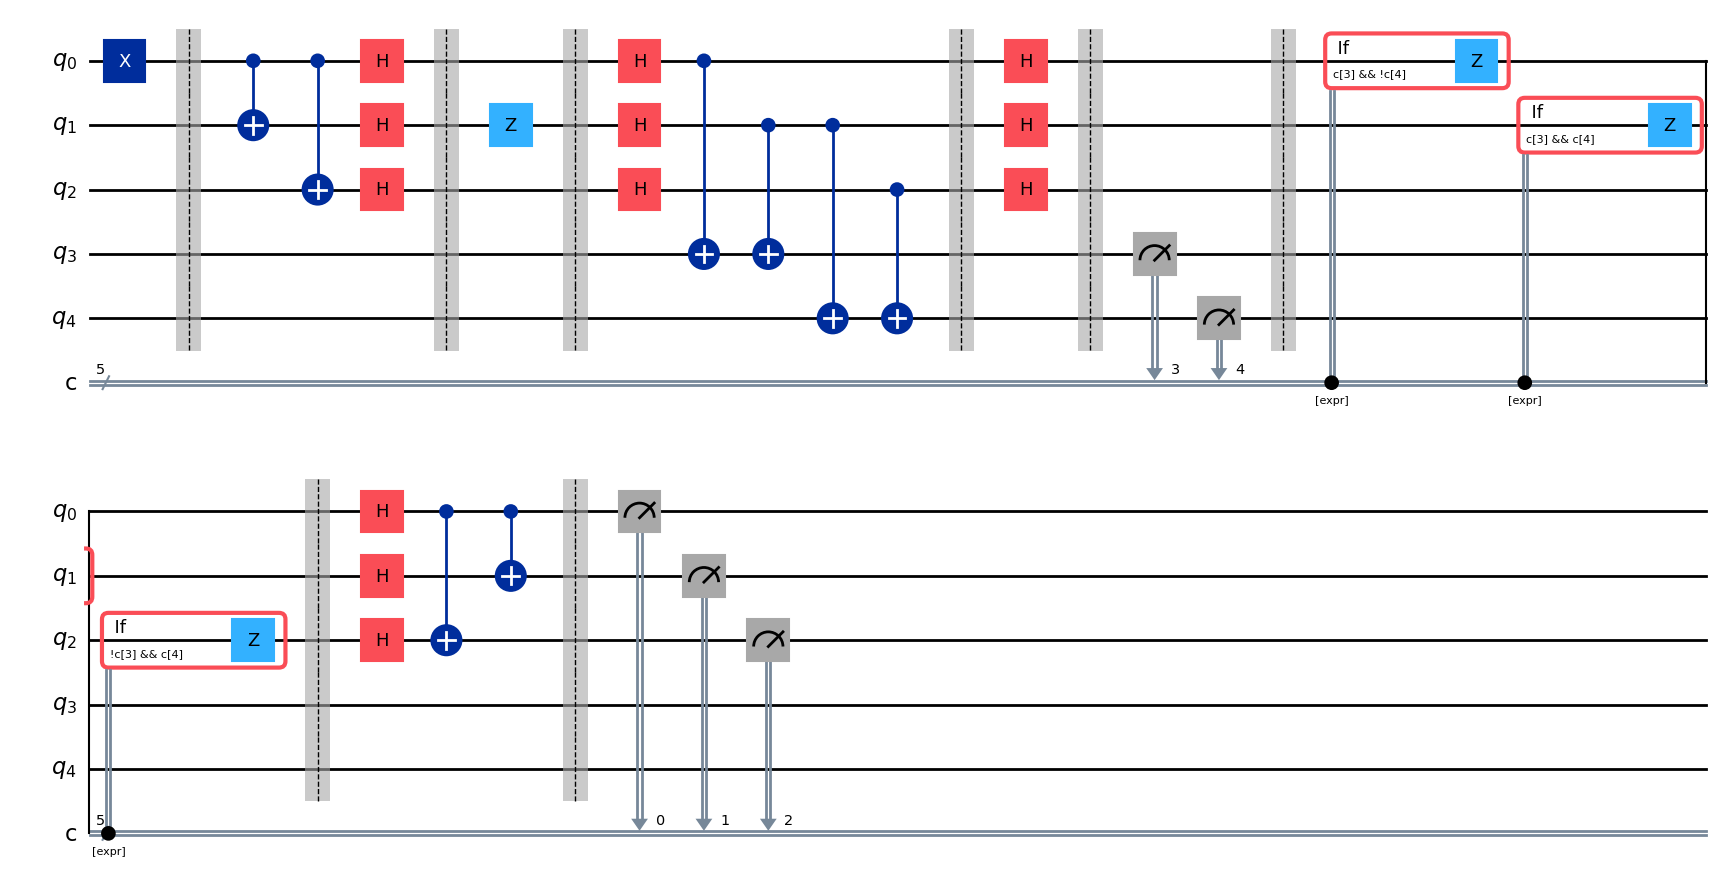

In [58]:
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts
from qiskit.circuit import ControlledGate
from qiskit.circuit.classical import expr
import math

# Three qubit phase-flip error-correcting code

flip = QuantumCircuit(5,5)

flip.x(0)
# flip.h(0)

flip.barrier()

flip.cx(0,1)
flip.cx(0,2)
flip.h([0,1,2])

flip.barrier()

flip.z(1)

flip.barrier()

flip.h([0,1,2])

flip.cx(0,3)
flip.cx(1,3)
flip.cx(1,4)
flip.cx(2,4)


flip.barrier()
flip.h([0,1,2])

flip.barrier()

flip.measure([3,4], [3,4])

flip.barrier()

with flip.if_test(expr.logic_and(flip.clbits[3],expr.logic_not(flip.clbits[4]))):
    flip.z(0)

with flip.if_test(expr.logic_and(flip.clbits[3],flip.clbits[4])):
    flip.z(1)

with flip.if_test(expr.logic_and(expr.logic_not(flip.clbits[3]),flip.clbits[4])):
    flip.z(2)

flip.barrier()

flip.h([0,1,2])

# decoding
flip.cx(0,2)
flip.cx(0,1)



flip.barrier()

flip.measure([0,1,2], [0,1,2])

flip.draw("mpl")
# In a similar way to the bit-flip error-correcting code, implement the phase-flip error-correcting code.
# Check that the code can correct a single phase flip but not two or more simultaneous phase flips.
# What happens if you introduce a bit flip?
# The next cell still has the simulation and measurement. Implement the phase flip code on the same qubits
# as for the bit flip code, so you can reuse the simulation and measurement.



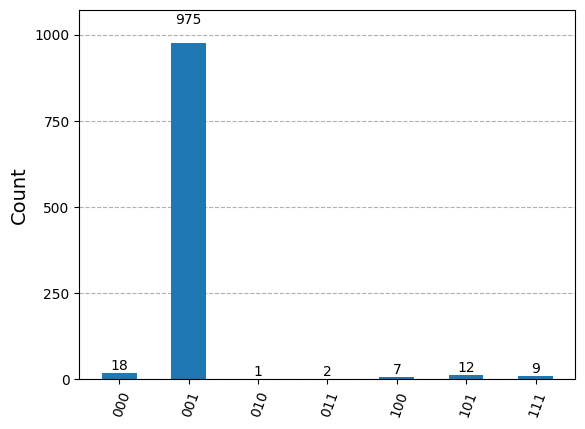

In [59]:

# Simulate and plot results

backend = GenericBackendV2(num_qubits=5, control_flow=True)
compiled = transpile(flip, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
# We only want to see the results for bits 0, 1, 2
mcounts = marginal_counts(counts,indices=[0,1,2])
plot_histogram(mcounts)